# Visualize LRB DEM Stability-Check Results

This notebook mirrors `Visualize LRB Stab Check Results.ipynb` and is configured for the one-ancilla `folded_qutrit` SI1000 DEM run. By default it resolves the run through `working-folder-folded_qutrit.txt`; set `DEM_RUN_NAME` explicitly if needed.

## What this notebook produces

- Constant-check diagnostic plots from the finalized DEM LRB stats
- Uniform-check plots across the DEM probability sweep
- Optional GIF animations for probability/check sweeps
- Mixed LRB-vs-RB tables and threshold-style summaries using the completed physical RB comparison grid
- Pseudo-threshold trend plots across uniform interval checks

## Data completeness note

Before producing comparison graphs, the notebook requires all physical RB comparison CSVs and verifies every coordinate satisfies `λ_LRB = 5p_raw = p_RB`. It raises an error instead of silently pairing incompatible RB data.

### 0. Quick environment check

This verifies that `sdim` is available in the active kernel before plotting utilities are imported.

In [1]:
from importlib.metadata import version
version("sdim")

'1.3.4'

### 1. Shared imports and configuration

This setup is copied from the original LRB visualization notebook, with the probability sample indices chosen to mimic the broad range used in the earlier RB/LRB notebook, RB fits fixed to zero offset (`rb_a_fixed=0.0`), and LRB-vs-RB comparisons using LRB `λ = 5p_raw` against physical RB `p = λ` from the completed comparison grid.

In [2]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "lrb" / "lrb_plotting.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/lrb/lrb_plotting.py")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import lrb.lrb_plotting as _lrb_plotting
import lrb.lrb_gif_plotting as _lrb_gif_plotting

# Ensure notebook uses latest local edits to plotting/GIF modules.
importlib.reload(_lrb_plotting)
importlib.reload(_lrb_gif_plotting)

from lrb.lrb_plotting import (
    LRBPlotFitConfig,
    LRBResultsPlotter,
    LRBThresholdConfig,
    LRBPaperPlotConfig,
)
from lrb.lrb_gif_plotting import LRBGifAnimator, LRBGifRenderConfig


def resolve_working_folder(
    code_name: str,
    lrb_root=None,
) -> str:
    root = Path(lrb_root) if lrb_root is not None else REPO_ROOT / "LRB-experiment-data-slurm"
    code_marker = root / f"working-folder-{code_name}.txt"
    legacy_marker = root / "working-folder.txt"

    def marker_path(marker: Path):
        if not marker.exists():
            return None
        run_name = marker.read_text(encoding="utf-8").strip()
        if not run_name:
            return None
        run_path = root / run_name
        if not run_path.exists():
            return None
        return str(run_path) + "/"

    for marker in (code_marker, legacy_marker):
        maybe_path = marker_path(marker)
        if maybe_path is not None:
            return maybe_path

    candidates = sorted(
        root.glob(f"Run-*-{code_name}*"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        return str(candidates[0]) + "/"

    raise FileNotFoundError(
        f"No run folder found for code '{code_name}' under {root.resolve()}"
    )


fit_config = LRBPlotFitConfig(
    a_fixed=0.0,
    y_ceiling=1.0,
    min_fit_points_lrb=2,
    min_fit_points_rb=3,
    f_min=1e-8,
    f_max=1.0000000,
    rb_a_fixed=0.0,
    p_axis_scale=5.0,
    p_axis_label="Normalized SI1000 Noise Strength λ = 5p",
    p_axis_symbol="λ",
    p_axis_column="lambda",
)

threshold_config = LRBThresholdConfig(
    tol=5e-4,
    require_consecutive=2,
    ignore_first_n=3,
    err_floor=2e-3,
    tail_min_prefix=6,
    tail_drop_tol_abs=0.01,
    tail_drop_tol_rel=0.25,
    p_min=None,
    p_max=None,
    min_lrb_n_points_keep=0,
    min_rb_n_points_keep=0,
    zoom_half_window_points=4,
    zoom_pad_frac=0.25,
    min_zoom_span=0.01,
    p_window_before_points=8,
    p_window_after_points=5,
    min_points_in_view=6,
    view_pad_frac=0.15,
    bootstrap_reps_error=500,
    bootstrap_reps_threshold=1000,
    bootstrap_ci_level=0.68,
    bootstrap_use_sem=True,
    bootstrap_seed=12345,
    paper_mode=True,
    paper_cols=2,
    paper_panel_width_in=3.2,
    paper_panel_height_in=2.5,
)

# Shared check ranges for all multi-check plotting/table methods.
const_check_min = 0
const_check_max = 0
unif_check_min = 1
unif_check_max = 22

# Optional pseudo-threshold fit controls.
pseudo_do_fit = False
pseudo_fit_model = "exp"  # or "poly"
pseudo_fit_degree = 1


gif_render_config = LRBGifRenderConfig(
    fps=10,
    dpi=120,
    hold_frames=1,
    transition_frames=6,
)

paper_plot_config = LRBPaperPlotConfig(
    enabled=True,
    column_layout="double",
    rows_per_page=3,
    pairs_per_row=2,
    num_prob_samples=6,
    # Closest available matched λ=p_RB points to the older notebook's
    # visual range: 3.36e-05, 0.0206, 0.0362, 0.0636, 0.0926, 0.144.
    prob_sample_indices=(0, 6, 7, 9, 11, 12),
    row_height_in=1.6,
    panel_title_fontsize=7.0,
    axis_label_fontsize=6.6,
    tick_fontsize=6.0,
    legend_fontsize=5.7,
    line_width=0.85,
    marker_size=2.6,
    errorbar_capsize=1.2,
    show_legend_first_row_only=False,
    compact_fit_legend=True,
    legend_on_rejected_panel=True,
)

def show_error_rate_uncertainty_table(table_csv: str, label: str) -> pd.DataFrame:
    frame = pd.read_csv(table_csv)
    coordinate_columns = [
        c for c in ("lrb_lambda", "rb_p", "lambda", "p_raw", "p")
        if c in frame.columns
    ]
    sort_column = "lrb_lambda" if "lrb_lambda" in frame.columns else coordinate_columns[0]
    needed = [
        "check_num",
        *coordinate_columns,
        "lrb_error_rate",
        "lrb_error_rate_ci_low",
        "lrb_error_rate_ci_high",
        "rb_error_rate",
        "rb_error_rate_ci_low",
        "rb_error_rate_ci_high",
    ]
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise ValueError(
            f"Missing uncertainty columns in {table_csv}: {missing}. "
            "Re-run the table generation cell."
        )

    view = frame[needed].copy()
    view["lrb_unc_minus"] = view["lrb_error_rate"] - view["lrb_error_rate_ci_low"]
    view["lrb_unc_plus"] = view["lrb_error_rate_ci_high"] - view["lrb_error_rate"]
    view["rb_unc_minus"] = view["rb_error_rate"] - view["rb_error_rate_ci_low"]
    view["rb_unc_plus"] = view["rb_error_rate_ci_high"] - view["rb_error_rate"]
    view = view.sort_values(["check_num", sort_column]).reset_index(drop=True)

    print(f"[{label}] error-rate uncertainty table")
    display(view)
    return view

def show_pseudo_threshold_uncertainty_table(
    summary_csv: str,
    label: str,
    check_min=None,
    check_max=None,
) -> pd.DataFrame:
    frame = pd.read_csv(summary_csv)
    threshold_column = (
        "threshold_lrb_lambda"
        if "threshold_lrb_lambda" in frame.columns
        else "threshold_lambda"
        if "threshold_lambda" in frame.columns
        else "threshold_p"
    )
    threshold_std_column = f"{threshold_column}_std_boot"
    threshold_ci_low_column = f"{threshold_column}_ci_low"
    threshold_ci_high_column = f"{threshold_column}_ci_high"
    needed = ["check_num", threshold_column]
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise ValueError(
            f"Missing pseudo-threshold columns in {summary_csv}: {missing}. "
            "Re-run threshold generation first."
        )

    view = frame.copy()
    if check_min is not None:
        view = view[view["check_num"] >= int(check_min)]
    if check_max is not None:
        view = view[view["check_num"] <= int(check_max)]
    view = view[view[threshold_column].notna()].copy()

    keep = ["check_num", threshold_column]
    has_std = threshold_std_column in view.columns
    has_ci = (
        threshold_ci_low_column in view.columns
        and threshold_ci_high_column in view.columns
    )
    if has_std:
        keep.append(threshold_std_column)
    if has_ci:
        keep.extend([threshold_ci_low_column, threshold_ci_high_column])

    table = view[keep].copy()
    if has_ci:
        table["threshold_unc_minus"] = (
            table[threshold_column] - table[threshold_ci_low_column]
        )
        table["threshold_unc_plus"] = (
            table[threshold_ci_high_column] - table[threshold_column]
        )
    elif has_std:
        table["threshold_unc_minus"] = table[threshold_std_column]
        table["threshold_unc_plus"] = table[threshold_std_column]
    else:
        raise ValueError(
            f"No pseudo-threshold uncertainty columns found in {summary_csv}."
        )

    table = table.sort_values(["check_num"]).reset_index(drop=True)
    print(f"[{label}] pseudo-threshold uncertainty table")
    display(table)
    return table

### 2. DEM run selection and output audit

The run path is explicit so this notebook does not depend on mutable `working-folder-*.txt` pointers. The audit confirms which result families are present before plotting.

In [3]:
DEM_CODE_NAME = "folded_qutrit"
DEM_RUN_NAME = None  # Set a run-folder name to override the code-specific marker.
if DEM_RUN_NAME is None:
    dem_working_folder_path = Path(resolve_working_folder(DEM_CODE_NAME)).resolve()
else:
    dem_working_folder_path = REPO_ROOT / "LRB-experiment-data-slurm" / DEM_RUN_NAME
dem_working_folder = str(dem_working_folder_path) + "/"
print(f"DEM working folder: {dem_working_folder}")

if not dem_working_folder_path.exists():
    raise FileNotFoundError(dem_working_folder_path)
if (dem_working_folder_path / "code_name.txt").read_text().strip() != DEM_CODE_NAME:
    raise ValueError(f"Expected one-ancilla code profile {DEM_CODE_NAME}.")
if (dem_working_folder_path / "noise_model.txt").read_text().strip() != "si1000":
    raise ValueError("The selected one-ancilla run is not an SI1000 run.")


def read_int_list(path: Path) -> list[int]:
    return [int(v) for v in path.read_text().replace(",", " ").split()]


def read_float_list(path: Path) -> list[float]:
    return [float(v) for v in path.read_text().replace(",", " ").split()]


def summarize_dem_outputs(run_path: Path) -> pd.DataFrame:
    probs = read_float_list(run_path / "probs.txt")
    const_checks = read_int_list(run_path / "check_const.txt")
    unif_checks = read_int_list(run_path / "check_unif.txt")
    rows = []
    for idx, prob in enumerate(probs):
        progress_path = run_path / "progress" / str(idx)
        lrb_path = run_path / "results" / "LRB" / str(idx)
        rb_path = run_path / "results" / "RB" / f"{idx}.csv"
        rb_comparison_path = run_path / "results" / "RB_comparison" / f"{idx}.csv"
        lambda_value = 5.0 * prob
        rb_comparison_p = None
        if rb_comparison_path.exists():
            for line in rb_comparison_path.read_text().splitlines():
                cells = [cell.strip() for cell in line.split(",")]
                if cells and cells[0].lower() == "probability" and len(cells) > 1:
                    rb_comparison_p = float(cells[1])
                    break
        const_csvs = list((lrb_path / "const_check_data").glob("*.csv"))
        unif_csvs = list((lrb_path / "unif_check_data").glob("*.csv"))
        rows.append(
            {
                "p_index": idx,
                "p_raw": prob,
                "lambda": lambda_value,
                "shots_remaining": int((progress_path / "shots_processed.txt").read_text().strip()),
                "done_flag": (progress_path / "done.txt").read_text().strip(),
                "const_csvs": len(const_csvs),
                "expected_const_csvs": len(const_checks),
                "unif_csvs": len(unif_csvs),
                "expected_unif_csvs": len(unif_checks),
                "rb_raw_csv_present": rb_path.exists(),
                "rb_comparison_csv_present": rb_comparison_path.exists(),
                "rb_comparison_p": rb_comparison_p,
                "rb_comparison_matches_lambda": (
                    rb_comparison_p is not None
                    and abs(rb_comparison_p - lambda_value) < 1e-12
                ),
            }
        )
    return pd.DataFrame(rows)


dem_output_audit = summarize_dem_outputs(dem_working_folder_path)
display(dem_output_audit)
print(
    f"LRB CSVs: {dem_output_audit['const_csvs'].sum() + dem_output_audit['unif_csvs'].sum()} / "
    f"{dem_output_audit['expected_const_csvs'].sum() + dem_output_audit['expected_unif_csvs'].sum()}"
)
print(f"Raw RB CSVs present: {dem_output_audit['rb_raw_csv_present'].sum()} / {len(dem_output_audit)}")
print(
    f"Comparison RB CSVs present: {dem_output_audit['rb_comparison_csv_present'].sum()} / "
    f"{len(dem_output_audit)}"
)
print(
    f"Comparison RB p matches λ: {dem_output_audit['rb_comparison_matches_lambda'].sum()} / "
    f"{len(dem_output_audit)}"
)
incompatible_rb_rows = dem_output_audit[~dem_output_audit['rb_comparison_matches_lambda']]
if not incompatible_rb_rows.empty:
    raise ValueError(
        "DEM graphs require one physical RB result per LRB point with "
        "p_RB = λ_LRB = 5p_raw. Missing or incompatible indices: "
        + ", ".join(str(v) for v in incompatible_rb_rows['p_index'])
    )

DEM working folder: /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/


,p_index,p_raw,lambda,shots_remaining,done_flag,const_csvs,expected_const_csvs,unif_csvs,expected_unif_csvs,rb_raw_csv_present,rb_comparison_csv_present,rb_comparison_p,rb_comparison_matches_lambda
0,0,0.0000,0.0000,0,1,23,23,22,22,True,True,0.0000,True
1,1,0.0001,0.0005,0,1,23,23,22,22,True,True,0.0005,True
2,2,0.0002,0.0010,0,1,23,23,22,22,True,True,0.0010,True
3,3,0.0005,0.0025,0,1,23,23,22,22,True,True,0.0025,True
4,4,0.0010,0.0050,0,1,23,23,22,22,True,True,0.0050,True
5,5,0.0020,0.0100,0,1,23,23,22,22,True,True,0.0100,True
6,6,0.0050,0.0250,0,1,23,23,22,22,True,True,0.0250,True
7,7,0.0075,0.0375,0,1,23,23,22,22,True,True,0.0375,True
8,8,0.0100,0.0500,0,1,23,23,22,22,True,True,0.0500,True
9,9,0.0125,0.0625,0,1,23,23,22,22,True,True,0.0625,True


LRB CSVs: 675 / 675
Raw RB CSVs present: 15 / 15
Comparison RB CSVs present: 15 / 15
Comparison RB p matches λ: 15 / 15


### 3. Build DEM plotter

Construct a `LRBResultsPlotter` for the DEM run using the shared fit configuration.

In [4]:
dem_plotter = LRBResultsPlotter(
    working_folder=dem_working_folder,
    fit_config=fit_config,
)
print(f"Code: {dem_plotter.code_name}")
print(f"Depths: {dem_plotter.depths}")
print(f"Raw p values: {dem_plotter.raw_probabilities}")
print(f"Displayed λ values: {dem_plotter.probabilities}")
print(f"Constant checks: {dem_plotter.stab_const}")
print(f"Uniform checks: {dem_plotter.stab_unif}")
rb_source, rb_probabilities = dem_plotter._rb_table_source()
max_lambda_rb_delta = max(
    abs(lambda_value - rb_value)
    for lambda_value, rb_value in zip(dem_plotter.probabilities, rb_probabilities)
)
print(f"RB comparison source: {rb_source}")
print(f"RB p values: {rb_probabilities}")
print(f"max |λ - p_RB|: {max_lambda_rb_delta:.3g}")
if max_lambda_rb_delta > 1e-12:
    raise ValueError("RB comparison grid is not paired with λ_LRB.")

Code: folded_qutrit
Depths: [0, 2, 4, 6, 10, 14, 18, 20, 22]
Raw p values: [0.0, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.0075, 0.01, 0.0125, 0.015, 0.02, 0.03, 0.04, 0.05]
Displayed λ values: [0.0, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.0375, 0.05, 0.0625, 0.075, 0.1, 0.15, 0.2, 0.25]
Constant checks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Uniform checks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
RB comparison source: /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/RB_comparison
RB p values: [0.0, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.0375, 0.05, 0.0625, 0.075, 0.1, 0.15, 0.2, 0.25]
max |λ - p_RB|: 0


### 4. Constant-check plots

Generate constant-check diagnostic panels. The default below matches the original notebook and plots `const_check=0`; raise `dem_const_check_max` to scan more constant-check values.

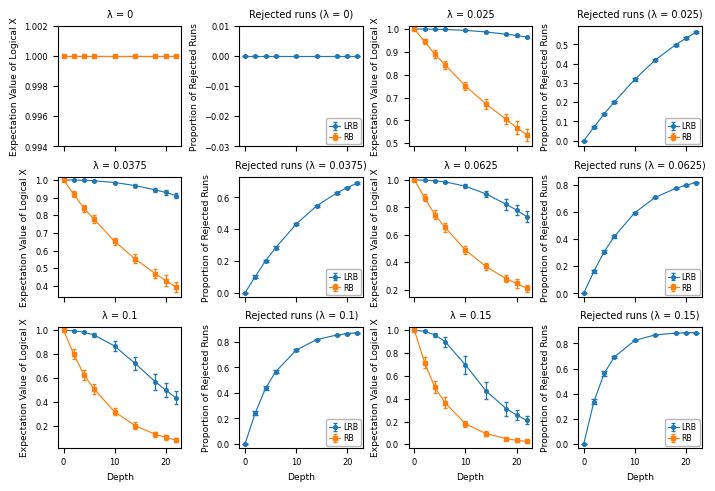

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/const-0-Summary-Graph-NoFit.pdf
Generated 1 DEM constant-check plots.


['/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/const-0-Summary-Graph-NoFit.pdf']

In [5]:
dem_const_check_min = 0
dem_const_check_max = 0

dem_const_outputs = dem_plotter.plot_all_const_checks(
    show=True,
    check_min=dem_const_check_min,
    check_max=dem_const_check_max,
    paper_config=paper_plot_config,
)
print(f"Generated {len(dem_const_outputs)} DEM constant-check plots.")
dem_const_outputs

### 5. Uniform-check plots

Generate uniform-check panels. The default mirrors the original quick-look range `1..4`; set `dem_unif_check_max = unif_check_max` to plot all interval checks.

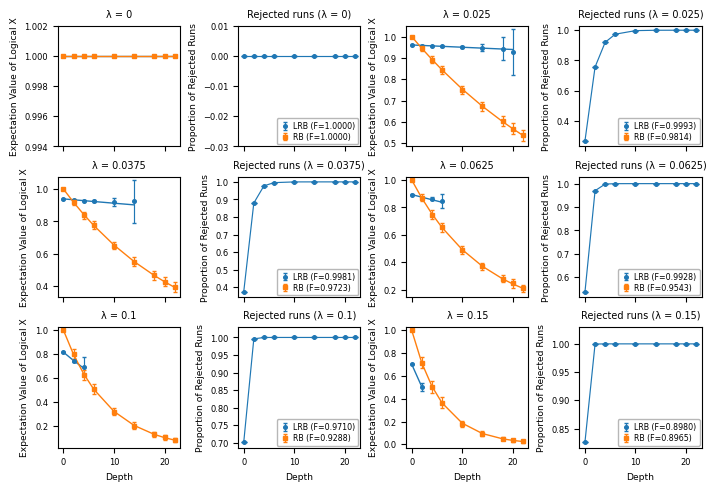

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-1-Summary-Graph-Fit.pdf


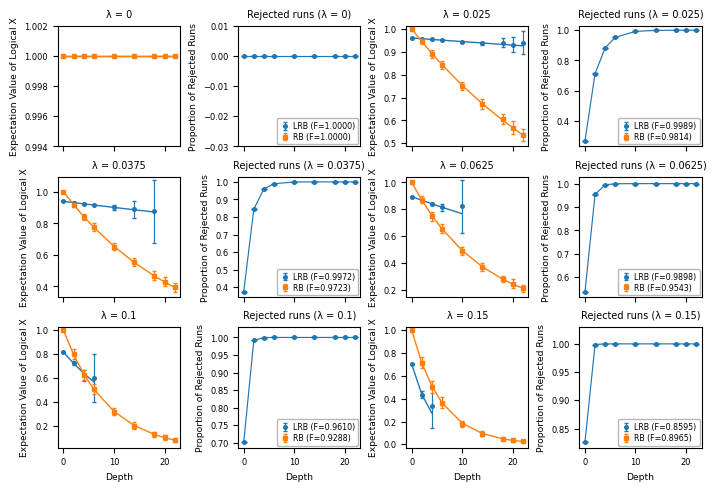

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-2-Summary-Graph-Fit.pdf


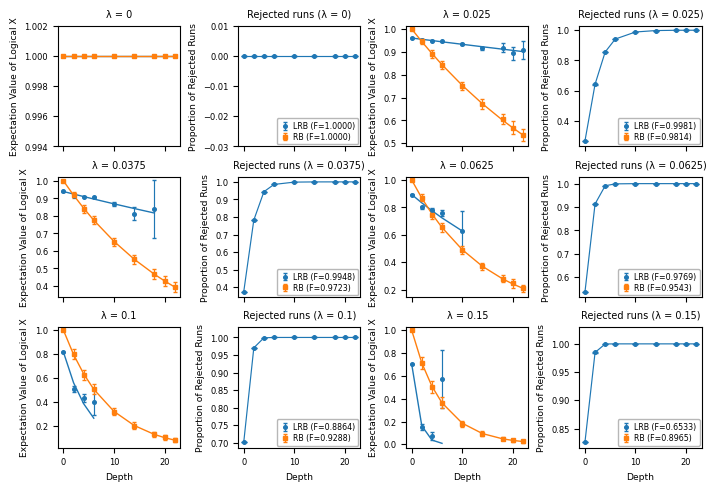

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-3-Summary-Graph-Fit.pdf


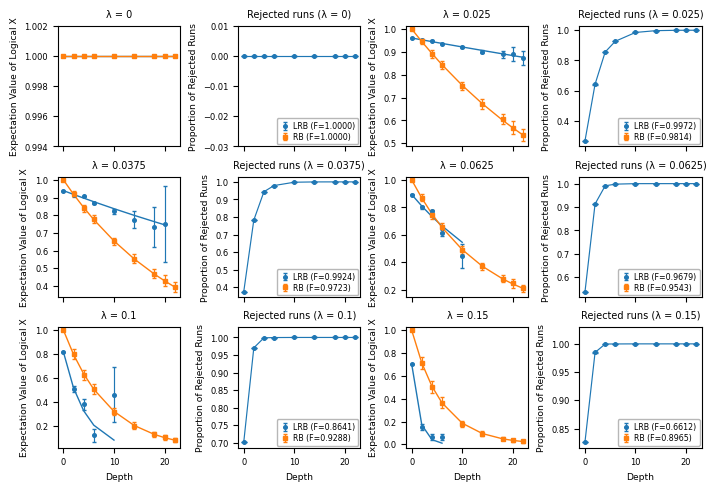

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-4-Summary-Graph-Fit.pdf
Generated 4 DEM uniform-check plots.


['/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-1-Summary-Graph-Fit.pdf',
 '/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-2-Summary-Graph-Fit.pdf',
 '/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-3-Summary-Graph-Fit.pdf',
 '/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-4-Summary-Graph-Fit.pdf']

In [6]:
dem_unif_check_min = 1
dem_unif_check_max = 4

dem_unif_outputs = dem_plotter.plot_all_unif_checks(
    show=True,
    check_min=dem_unif_check_min,
    check_max=dem_unif_check_max,
    paper_config=paper_plot_config,
)
print(f"Generated {len(dem_unif_outputs)} DEM uniform-check plots.")
dem_unif_outputs

### 6. GIF animations

These are optional and can take a bit longer. They use the same animation helpers as the original notebook.

In [7]:
dem_gif_animator = LRBGifAnimator(
    dem_plotter,
    render_config=gif_render_config,
)

# Regenerating every GIF is slow. Leave this False for normal notebook reruns;
# set True only when the GIF source data or rendering code changed.
regenerate_dem_gifs = True

expected_dem_interval_gifs = [
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx00-p0.00e+00.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx01-p5.00e-04.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx02-p1.00e-03.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx03-p2.50e-03.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx04-p5.00e-03.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx05-p1.00e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx06-p2.50e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx07-p3.75e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx08-p5.00e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx09-p6.25e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx10-p7.50e-02.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx11-p1.00e-01.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx12-p1.50e-01.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx13-p2.00e-01.gif",
    dem_gif_animator.out_dir / "unif-interval-sweep-pidx14-p2.50e-01.gif",
]

if regenerate_dem_gifs:
    dem_const_p_gif = dem_gif_animator.create_const_sweep_gif(
        const_check=0,
        strict=True,
    )
    dem_unif_interval_gifs = dem_gif_animator.create_unif_interval_gifs_for_all_probabilities(
        interval_min=1,
        interval_max=22,
        strict=True,
    )
else:
    dem_const_p_gif = str(dem_gif_animator.out_dir / "const-0-rb-lrb-vs-p.gif")
    dem_unif_interval_gifs = [str(path) for path in expected_dem_interval_gifs]
    missing_gifs = [path for path in [Path(dem_const_p_gif), *expected_dem_interval_gifs] if not path.exists()]
    if missing_gifs:
        raise FileNotFoundError(
            "Missing pre-rendered DEM GIFs; set regenerate_dem_gifs=True and rerun this cell: "
            + ", ".join(str(path) for path in missing_gifs)
        )

print(f"DEM const=0 sweep GIF: {dem_const_p_gif}")
print(f"Available {len(dem_unif_interval_gifs)} DEM interval-sweep GIFs.")
for gif_path in dem_unif_interval_gifs:
    print(Path(gif_path).name)


DEM const=0 sweep GIF: /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/gifs/const-0-rb-lrb-vs-p.gif
Available 15 DEM interval-sweep GIFs.
unif-interval-sweep-pidx00-p0.00e+00.gif
unif-interval-sweep-pidx01-p5.00e-04.gif
unif-interval-sweep-pidx02-p1.00e-03.gif
unif-interval-sweep-pidx03-p2.50e-03.gif
unif-interval-sweep-pidx04-p5.00e-03.gif
unif-interval-sweep-pidx05-p1.00e-02.gif
unif-interval-sweep-pidx06-p2.50e-02.gif
unif-interval-sweep-pidx07-p3.75e-02.gif
unif-interval-sweep-pidx08-p5.00e-02.gif
unif-interval-sweep-pidx09-p6.25e-02.gif
unif-interval-sweep-pidx10-p7.50e-02.gif
unif-interval-sweep-pidx11-p1.00e-01.gif
unif-interval-sweep-pidx12-p1.50e-01.gif
unif-interval-sweep-pidx13-p2.00e-01.gif
unif-interval-sweep-pidx14-p2.50e-01.gif


### 7. Mixed LRB-vs-RB tables and threshold summaries

This repeats the original notebook's table/threshold workflow. For the comparison plots, LRB error rates are placed at `lrb_lambda = 5p_raw`, while physical RB error rates are placed at the matched coordinate `rb_p = lrb_lambda` from `results/RB_comparison`.

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif_lrb_vs_rb_table_all_mixed_fits.csv
[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-1-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-2-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-3-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-4-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote /pscratch/sd/s/so

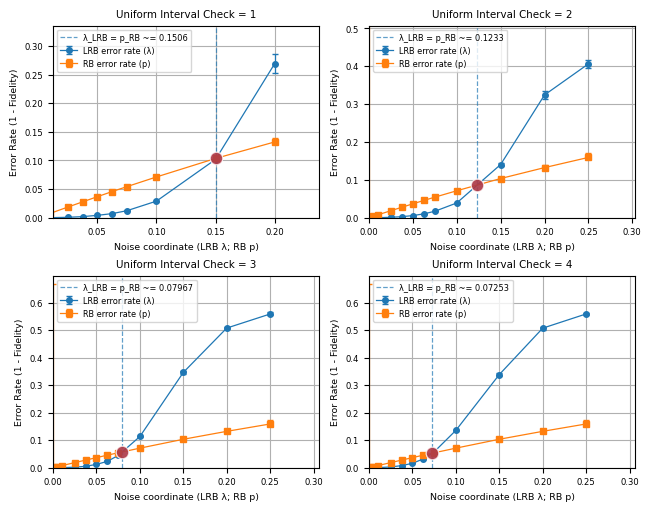

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-threshold-error-vs-p-paper-grid.pdf
[THRESHOLD] Uniform Interval Check = 1: λ_LRB = p_RB = 0.150569 +- 0.00247
[THRESHOLD] Uniform Interval Check = 2: λ_LRB = p_RB = 0.123274 +- 0.00134
[THRESHOLD] Uniform Interval Check = 3: λ_LRB = p_RB = 0.0796682 +- 0.000573
[THRESHOLD] Uniform Interval Check = 4: λ_LRB = p_RB = 0.0725304 +- 0.000871
[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif_thresholds_summary_monotone_trim_zoom_pwindow.csv
[single_ancilla_si1000_dem] error-rate uncertainty table


,check_num,lrb_lambda,rb_p,lambda,p_raw,p,lrb_error_rate,lrb_error_rate_ci_low,lrb_error_rate_ci_high,rb_error_rate,rb_error_rate_ci_low,rb_error_rate_ci_high,lrb_unc_minus,lrb_unc_plus,rb_unc_minus,rb_unc_plus
0,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000e+00,0.000000e+00,3.333333e-08,0.000000,0.000007,0.666667,0.000000e+00,3.333333e-08,-0.000007,0.666667
1,1,0.0005,0.0005,0.0005,0.0001,0.0005,4.690000e-07,2.680000e-07,6.733333e-07,0.000376,0.000399,0.005365,2.010000e-07,2.043333e-07,-0.000023,0.004989
2,1,0.0010,0.0010,0.0010,0.0002,0.0010,6.060000e-07,3.350000e-07,8.796667e-07,0.000741,0.000347,0.004416,2.710000e-07,2.736667e-07,0.000394,0.003675
3,1,0.0025,0.0025,0.0025,0.0005,0.0025,4.803230e-06,4.209945e-06,5.344920e-06,0.001876,0.000783,0.003995,5.932850e-07,5.416900e-07,0.001093,0.002119
4,1,0.0050,0.0050,0.0050,0.0010,0.0050,2.033121e-05,1.921238e-05,2.142553e-05,0.003757,0.003339,0.006554,1.118825e-06,1.094326e-06,0.000417,0.002797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,22,0.0750,0.0750,0.0750,0.0150,0.0750,1.660683e-01,1.656309e-01,1.664813e-01,0.054289,0.053500,0.056051,4.373333e-04,4.130560e-04,0.000789,0.001762
326,22,0.1000,0.1000,0.1000,0.0200,0.1000,2.661675e-01,2.651974e-01,2.673384e-01,0.071206,0.070848,0.073214,9.700267e-04,1.170923e-03,0.000358,0.002008
327,22,0.1500,0.1500,0.1500,0.0300,0.1500,4.052096e-01,4.031667e-01,4.076543e-01,0.103527,0.103721,0.106290,2.042880e-03,2.444715e-03,-0.000193,0.002763
328,22,0.2000,0.2000,0.2000,0.0400,0.2000,4.956432e-01,4.902656e-01,5.018481e-01,0.132345,0.136151,0.138916,5.377643e-03,6.204885e-03,-0.003807,0.006571


[single_ancilla_si1000_dem] pseudo-threshold uncertainty table


,check_num,threshold_lrb_lambda,threshold_lrb_lambda_std_boot,threshold_lrb_lambda_ci_low,threshold_lrb_lambda_ci_high,threshold_unc_minus,threshold_unc_plus
0,1,0.150569,0.002474,0.147314,0.152018,0.003254,0.001449
1,2,0.123274,0.001336,0.122013,0.124688,0.001261,0.001415
2,3,0.079668,0.000573,0.079120,0.080266,0.000549,0.000597
3,4,0.072530,0.000871,0.071782,0.073499,0.000748,0.000969


('/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif_lrb_vs_rb_table_all_mixed_fits.csv',
 '/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif_thresholds_summary_monotone_trim_zoom_pwindow.csv')

In [8]:
point_ci_columns = [
    "lrb_error_rate_std_boot",
    "lrb_error_rate_ci_low",
    "lrb_error_rate_ci_high",
    "rb_error_rate_std_boot",
    "rb_error_rate_ci_low",
    "rb_error_rate_ci_high",
]
dem_table_csv_path = Path(dem_plotter.out_dir) / "unif_lrb_vs_rb_table_all_mixed_fits.csv"
force_rebuild_uncertainty_table = False


def table_has_point_uncertainty(path: Path) -> bool:
    if not path.exists():
        return False
    columns = pd.read_csv(path, nrows=0).columns
    return all(col in columns for col in point_ci_columns)


if force_rebuild_uncertainty_table or not table_has_point_uncertainty(dem_table_csv_path):
    dem_table_csv = dem_plotter.build_unif_lrb_vs_rb_table_mixed_fits(
        write_per_check_tables=True,
        check_min=unif_check_min,
        check_max=unif_check_max,
        bootstrap_reps=threshold_config.bootstrap_reps_error,
        bootstrap_ci_level=threshold_config.bootstrap_ci_level,
        bootstrap_use_sem=threshold_config.bootstrap_use_sem,
        bootstrap_seed=threshold_config.bootstrap_seed,
    )
else:
    dem_table_csv = str(dem_table_csv_path)
    print(f"Reusing existing uncertainty table: {dem_table_csv}")

dem_summary_csv = dem_plotter.plot_all_unif_threshold_graphs(
    threshold_config=threshold_config,
    table_csv_path=dem_table_csv,
    show=True,
    check_min=unif_check_min,
    check_max=4,
)

dem_uncertainty_table = show_error_rate_uncertainty_table(
    dem_table_csv,
    label="single_ancilla_si1000_dem",
)
dem_pseudo_threshold_table = show_pseudo_threshold_uncertainty_table(
    dem_summary_csv,
    label="single_ancilla_si1000_dem",
    check_min=unif_check_min,
    check_max=unif_check_max,
)

dem_table_csv, dem_summary_csv

### 8. Pseudo-threshold trend vs interval check

This produces the same focused pseudo-threshold trend plot as the original notebook, using the quick-look `1..4` interval-check range by default.

[PSEUDO] Uniform Interval Check = 1: λ_LRB = p_RB = 0.150569 +- 0.00247
[PSEUDO] Uniform Interval Check = 2: λ_LRB = p_RB = 0.123274 +- 0.00134
[PSEUDO] Uniform Interval Check = 3: λ_LRB = p_RB = 0.0796682 +- 0.000573
[PSEUDO] Uniform Interval Check = 4: λ_LRB = p_RB = 0.0725304 +- 0.000871
[FIT] fit disabled by do_fit=False.


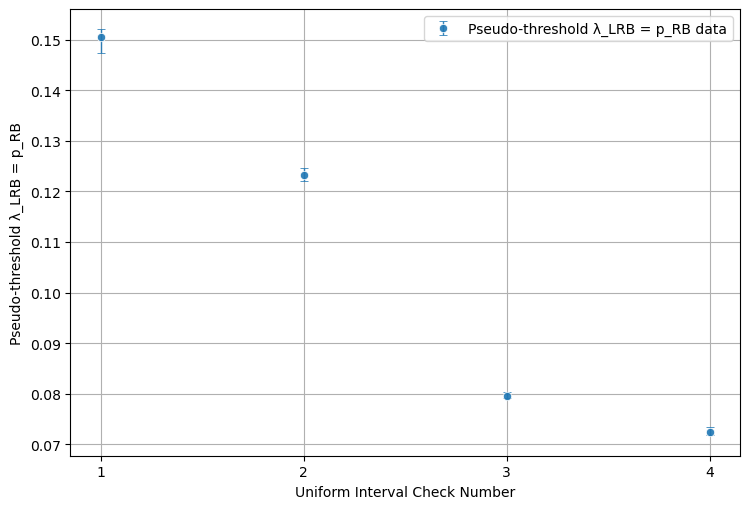

[OK] wrote /pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-1-to-4-pseudo-threshold-vs-interval-check-fit.pdf


'/pscratch/sd/s/sohan100/LRB-Simulations-sdim/LRB-experiment-data-slurm/Run-2026-08-04-23-58-49-folded_qutrit-single-ancilla-si1000/results/plots/unif-1-to-4-pseudo-threshold-vs-interval-check-fit.pdf'

In [9]:
dem_pseudo_fit_pdf = dem_plotter.plot_unif_pseudo_thresholds_vs_interval_check(
    check_min=unif_check_min,
    check_max=4,
    do_fit=pseudo_do_fit,
    fit_model=pseudo_fit_model,
    fit_degree=pseudo_fit_degree,
    paper_mode=paper_plot_config.enabled,
    show=True,
)

dem_pseudo_fit_pdf

## 9. Reading guide

Start with the generated constant/uniform PDFs under `results/plots`. For LRB-only DEM behavior, the summary plots are complete across all 15 probabilities. For LRB-vs-RB and pseudo-threshold interpretation, compare LRB at `lrb_lambda = 5p_raw` against physical RB at `rb_p = lrb_lambda`; generated tables retain `p_raw` for provenance.